# The Privacy Stress Harness — a guided tour

A hands-on tutorial and reference for `privacy_harness.py` and its two companion layers,
`cov_diagnostics.py` (structural) and `inference_eval.py` (inferential). By the end you will be able to point
the harness at *any* dataset, *any* release pipeline, and *any* noise mechanism, and get back a defensible
read on **privacy** and **utility**.

### The one-paragraph mental model

A release pipeline turns a set of subjects into an output (a mean image, a t-statistic, …). To protect it we
add noise. The harness asks two questions about that noised release: **can an attacker tell whether a given
person was in the input?** (privacy) and **how badly did the noise damage the output?** (utility). Everything
is built from swappable parts joined at clean seams, so you change one part without touching the rest.

### Design principles (worth stating up front)

- **Mechanism- and dataset-agnostic.** The engine only ever calls `source.sample(n, rng)` and
  `mechanism(y, D, S, …) → NoiseModel`. Swap either; nothing else changes.
- **A panel, not a number.** Utility is reported as several complementary metrics (magnitude, *spatial
  structure*, ordering, bias) because any single number hides a failure mode.
- **Advantage is a lower bound on leakage.** An attack that succeeds proves leakage; a failed attack does not
  prove safety. Numbers are evidence, compared *between* mechanisms — never a DP certificate.
- **`noise_power` is a fair-comparison knob, not ε.** Matching total noise variance across mechanisms
  isolates noise *shape* from noise *amount*. It is not a privacy budget.

## Architecture at a glance



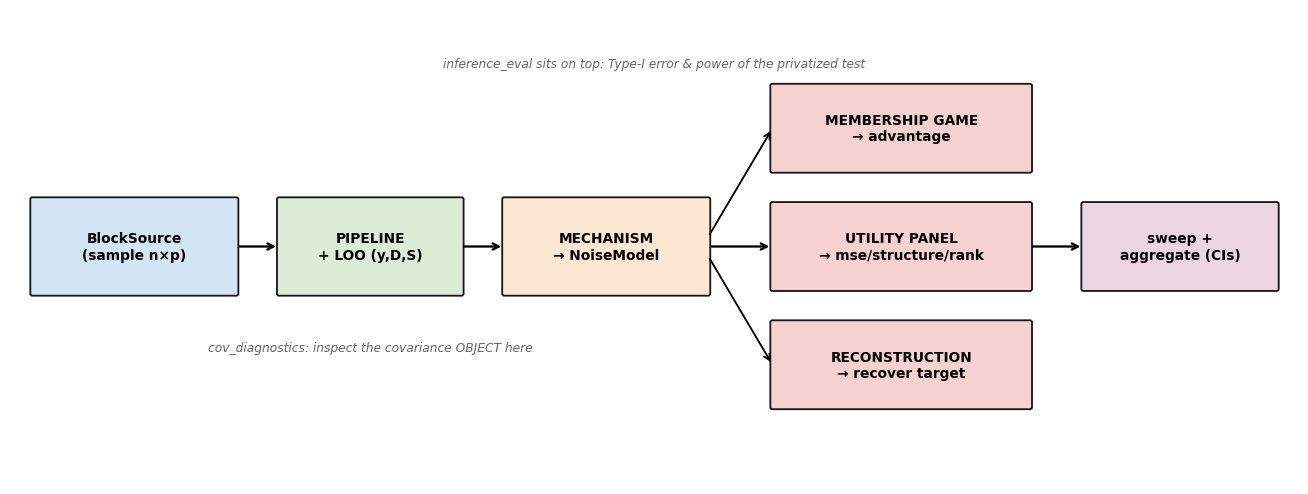

In [1]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3})
PAL = {"iid":"#4c72b0","cov_gaussian":"#dd8452","cov_rejection":"#55a868",
       "data":"#4c72b0","loo":"#dd8452","custom":"#8172b3","clean":"#333333"}

def _box(ax, x, y, w, h, text, fc):
    ax.add_patch(mpatches.FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.02,rounding_size=0.02",
                 fc=fc, ec="k", lw=1.2, alpha=.9))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=9, weight="bold")

fig, ax = plt.subplots(figsize=(12, 4.6)); ax.axis("off"); ax.set_xlim(0,12); ax.set_ylim(0,5)
_box(ax, 0.2, 2.0, 1.9, 1.0, "BlockSource\n(sample n×p)", "#cfe2f3")
_box(ax, 2.5, 2.0, 1.7, 1.0, "PIPELINE\n+ LOO (y,D,S)", "#d9ead3")
_box(ax, 4.6, 2.0, 1.9, 1.0, "MECHANISM\n→ NoiseModel", "#fce5cd")
_box(ax, 7.1, 3.3, 2.4, 0.9, "MEMBERSHIP GAME\n→ advantage", "#f4cccc")
_box(ax, 7.1, 2.05, 2.4, 0.9, "UTILITY PANEL\n→ mse/structure/rank", "#f4cccc")
_box(ax, 7.1, 0.8, 2.4, 0.9, "RECONSTRUCTION\n→ recover target", "#f4cccc")
_box(ax, 10.0, 2.05, 1.8, 0.9, "sweep +\naggregate (CIs)", "#ead1dc")
for x0,x1 in [(2.1,2.5),(4.2,4.6),(6.5,7.1)]:
    ax.annotate("", (x1,2.5),(x0,2.5), arrowprops=dict(arrowstyle="->",lw=1.5))
ax.annotate("", (7.1,3.75),(6.5,2.6), arrowprops=dict(arrowstyle="->",lw=1.2))
ax.annotate("", (7.1,1.25),(6.5,2.4), arrowprops=dict(arrowstyle="->",lw=1.2))
ax.annotate("", (10.0,2.5),(9.5,2.5), arrowprops=dict(arrowstyle="->",lw=1.5))
ax.text(3.35,1.4,"cov_diagnostics: inspect the covariance OBJECT here",ha="center",fontsize=8,style="italic",color="#666")
ax.text(6.0,4.4,"inference_eval sits on top: Type-I error & power of the privatized test",ha="center",fontsize=8,style="italic",color="#666")
plt.tight_layout(); plt.show()

## Setup

Put `privacy_harness.py`, `cov_diagnostics.py`, and `inference_eval.py` next to this notebook (or on the
path). No data files are needed — every example below is self-contained.

In [2]:
import sys, os
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        sys.path.insert(0, cand); break
import privacy_harness as ph
import cov_diagnostics as cd
import inference_eval as ie
print("harness:", [x for x in dir(ph) if not x.startswith('_')][:8], "...")
print("loaded privacy_harness, cov_diagnostics, inference_eval")

harness: ['ArrayBlockSource', 'BlockSource', 'GeneratedPopulationSource', 'NoiseModel', 'SyntheticBlockSource', 'TabularSource', 'aggregate_sweep', 'analytic_advantage'] ...
loaded privacy_harness, cov_diagnostics, inference_eval


## Part 1 — Block sources: where subjects come from



A **block source** is the harness's data-supply abstraction — the single seam through which *all* data
enters the engine, and the thing that makes the harness dataset-agnostic.

**The contract.** The engine never knows what your data is. It only ever asks a source for four things:

- `.block_shape` — the spatial shape of one unit of data
- `.p` — how many features that unit has once flattened (`p = ∏ block_shape`)
- `.N` — the cohort size to use in the membership game
- `.sample(n, rng) -> (n, p)` — return `n` subjects, each a length-`p` vector

`sample` is the *only* method the engine calls. Everything downstream — pipeline, LOO artifacts, mechanism,
attacks, utility panel — is written against that `(n, p)` array, so **swapping the source swaps the dataset
with zero changes anywhere else.**

**Why "block".** The name comes from the imaging origin: you don't privatize a whole brain volume at once,
you work with a small aligned spatial **patch** — a *block* of voxels, e.g. a `4×4×4` cube. Each subject
contributes one such block, flattened to a vector of `p = 64` values. `block_shape` keeps the spatial layout
(so utility metrics can un-flatten the vector and measure neighbour-correlation); `p` is just the flattened
length the mechanism and attacker see. For non-spatial data, `block_shape = (p,)` — the "block" is simply the
`p` columns, with no spatial neighbours.

**The four concrete sources** all satisfy this same contract:

| source | what it provides |
|---|---|
| `ArrayBlockSource(volumes, mask, …)` | real imaging: aligned `(subjects, X, Y, Z)` + mask → extracts one in-brain block, samples a fixed pool |
| `TabularSource(table)` | a fixed table of real subjects; `block_shape=(p,)` |
| `GeneratedPopulationSource(…)` | *synthesises* fresh subjects each call (population sweeps / characterization) |
| `SyntheticBlockSource(…)` | *synthesises* spatially-correlated blocks from a known covariance (no files) |

Real-data sources sample from a stored pool (`M` = total available, `N` = cohort size for the game);
generative sources draw new subjects every call. `ArrayBlockSource` is the plug-and-play path for real imaging: reduce a dataset to aligned volumes + a mask
and it just runs. It also enforces structural preconditions (shape/mask/finiteness/variance) and refuses
loudly otherwise — it cannot verify registration, so that remains the caller's responsibility.

**The precondition it enforces — and the one it can't.** `ArrayBlockSource` checks shape, mask agreement,
block-fits-in-volume, finiteness, and non-zero variance, and refuses loudly otherwise. It explicitly does
**not** verify *registration*: a block source assumes voxel *k* means the same anatomical location across
subjects. Alignment is the caller's responsibility — a stated contract, which is why the loaders say
"already-aligned."

*In one line:* a block source is a thin adapter that turns any dataset — real imaging, a folder of NIfTIs, a
tabular file, or a synthetic population — into a stream of aligned `(n, p)` subject blocks, the only data
shape the rest of the harness ever sees.

In [3]:
rng = np.random.default_rng(0)

# (a) tabular — a correlated bivariate table
tab = rng.multivariate_normal([70, 1.70], [[144, 0.7], [0.7, 0.01]], 200)
s_tab = ph.TabularSource(tab, N=60)

# (b) generated population — draws FRESH subjects each call (for population sweeps)
s_pop = ph.GeneratedPopulationSource(N=60, p=2, correlation=0.6, base_std=1.0)

# (c) synthetic spatial blocks — 4x4x4 patch with spatial correlation 0.7
s_syn = ph.SyntheticBlockSource(N=50, block_shape=(4, 4, 4), spatial_corr=0.7, base_std=1.0)

# (d) generic array source — stand in for a real (subjects, X, Y, Z) volume + mask
vols = rng.normal(size=(40, 8, 8, 8)) + np.linspace(0, 1, 8)[None, :, None, None]
s_arr = ph.ArrayBlockSource(vols, mask=np.ones((8, 8, 8), bool), block_shape=(2, 2, 2), N=30, seed=1)

for name, s in [("TabularSource", s_tab), ("GeneratedPopulationSource", s_pop),
                ("SyntheticBlockSource", s_syn), ("ArrayBlockSource", s_arr)]:
    x = s.sample(5, rng)
    print(f"{name:26s} block_shape={str(s.block_shape):10s} p={s.p:<3d} N={s.N:<3d} sample(5)->{x.shape}")

TabularSource              block_shape=(2,)       p=2   N=60  sample(5)->(5, 2)
GeneratedPopulationSource  block_shape=(2,)       p=2   N=60  sample(5)->(5, 2)
SyntheticBlockSource       block_shape=(4, 4, 4)  p=64  N=50  sample(5)->(5, 64)
ArrayBlockSource           block_shape=(2, 2, 2)  p=8   N=30  sample(5)->(5, 8)


**Writing your own source** is trivial — subclass `BlockSource` and implement `sample`. This is the only code
you need to add to run the whole harness on a new data type.

In [4]:
class TwoMoonsSource(ph.BlockSource):
    "A toy custom source: two correlated features with a heavy tail."
    def __init__(self, N=60):
        self.N = N; self.p = 2; self.block_shape = (2,)
    def sample(self, n, rng):
        a = rng.standard_t(df=3, size=(n, 1))
        return np.hstack([a, 0.7*a + rng.standard_normal((n, 1))])

s_custom = TwoMoonsSource()
print("custom source sample:", s_custom.sample(4, rng).shape, "| p =", s_custom.p)

custom source sample: (4, 2) | p = 2


## Part 2 — Pipelines, targets, and LOO artifacts

A **pipeline** maps a stack of subjects `(n, …)` to one output vector. Three are provided
(`pipeline_mean`, `pipeline_median`, `pipeline_variance`); any callable works. The harness never needs a
closed form — it computes the **leave-one-out (LOO) artifacts** numerically:

- `y  = pipeline(stack)` — the clean output.
- `D  = [pipeline(stack without i) − y]` for every subject *i* — each subject's **influence** on the release.
- `S  = max_i |D_i|` per coordinate — the **sensitivity** the mechanism must cover.

`loo_artifacts(stack, pipeline) -> (y, D, S)` is the single call that produces all three.

In [5]:
stack = s_tab.sample(40, rng)                     # (40, 2)
y, D, S = ph.loo_artifacts(stack, ph.pipeline_mean)
print("clean output  y :", np.round(y, 3), "  shape", y.shape)
print("LOO influences D:", D.shape, " (one row per subject)")
print("sensitivity   S :", np.round(S, 4), " = max |D| per coordinate")

# target_ksigma builds an explicit adversarial 'stress' target: mean + k*SD in every dimension
tgt = ph.target_ksigma(stack, k=2.0)
print("k-sigma target  :", np.round(tgt, 3))

clean output  y : [72.865  1.715]   shape (2,)
LOO influences D: (40, 2)  (one row per subject)
sensitivity   S : [0.6543 0.0059]  = max |D| per coordinate
k-sigma target  : [98.196  1.898]


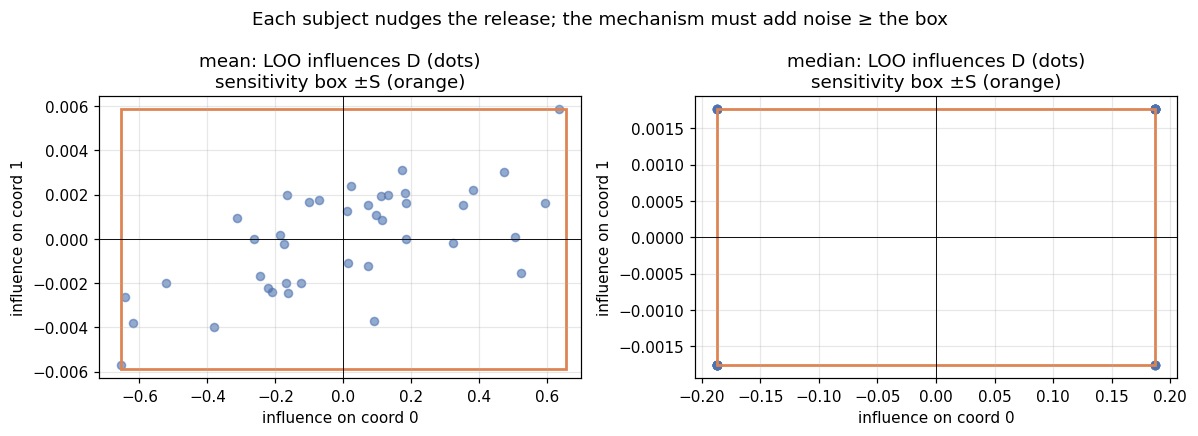

In [6]:
# Visualize the LOO influence cloud and the sensitivity box it induces
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (pname, pipe) in zip(ax, [("mean", ph.pipeline_mean), ("median", ph.pipeline_median)]):
    _, Dp, Sp = ph.loo_artifacts(stack, pipe)
    a.scatter(Dp[:, 0], Dp[:, 1], s=28, alpha=.6, color=PAL["iid"])
    a.axvline(0, color="k", lw=.6); a.axhline(0, color="k", lw=.6)
    a.add_patch(mpatches.Rectangle((-Sp[0], -Sp[1]), 2*Sp[0], 2*Sp[1], fill=False, ec=PAL["cov_gaussian"], lw=1.8))
    a.set_title(f"{pname}: LOO influences D (dots)\nsensitivity box ±S (orange)")
    a.set_xlabel("influence on coord 0"); a.set_ylabel("influence on coord 1")
plt.suptitle("Each subject nudges the release; the mechanism must add noise ≥ the box"); plt.tight_layout(); plt.show()

## Part 3 — Mechanisms and the `NoiseModel` seam

A **mechanism** is a function `mechanism(y, D, S, noise_power=None, **cfg) -> NoiseModel`. The returned
`NoiseModel` wraps a sampler and exposes:

- `.sample(rng)` — draw one noise vector;
- `.cov` — the noise covariance *iff the noise is exactly Gaussian* (enables the analytic oracle), else `None`;
- `.nominal_cov` — the covariance the mechanism *constructed*, for inspection, regardless of sampler;
- `.fallback_rate` — fraction of draws that hit a fallback path.

Built-in mechanisms:

| mechanism | noise shape |
|---|---|
| `mech_iid` | isotropic Gaussian |
| `mech_cov_gaussian` | Gaussian with covariance from the LOO cloud |
| `mech_cov_rejection` | same covariance, but **rejected** until `|z_j| ≥ S_j` (non-Gaussian) |
| `make_covsource_mechanism(cov_source, scale_rule)` | the reference family: correlation from `data` or `loo`; scale `supervisor` or `raw` |

The three named covsource variants — `mech_supervisor_data_corr`, `mech_supervisor_loo_corr`,
`mech_direct_loo_cov` — are the ones studied in notebooks 4–5.

In [7]:
# A standardized correlated stack (unit variances, small N) so noise SHAPE is legible in 2-D
demo_stack = np.random.default_rng(1).multivariate_normal([0, 0], [[1.0, 0.7], [0.7, 1.0]], 15)
y, D, S = ph.loo_artifacts(demo_stack, ph.pipeline_mean)
builders = {
    "iid":            lambda: ph.mech_iid(y, D, S, noise_power=1.0),
    "cov_gaussian":   lambda: ph.mech_cov_gaussian(y, D, S, noise_power=1.0),
    "cov_rejection":  lambda: ph.mech_cov_rejection(y, D, S, noise_power=1.0),
    "covsource_data": lambda: ph.make_covsource_mechanism("data")(y, D, S, noise_power=1.0, subjects=demo_stack),
    "covsource_loo":  lambda: ph.make_covsource_mechanism("loo")(y, D, S, noise_power=1.0, subjects=demo_stack),
}
for name, build in builders.items():
    m = build()
    gauss = "yes" if m.cov is not None else "no "
    tr = np.trace(np.atleast_2d(m.nominal_cov)) if m.nominal_cov is not None else np.nan
    print(f"{name:16s} exact-Gaussian(.cov)={gauss}  trace(nominal_cov)={tr:.3f}")

iid              exact-Gaussian(.cov)=yes  trace(nominal_cov)=1.000
cov_gaussian     exact-Gaussian(.cov)=yes  trace(nominal_cov)=1.000
cov_rejection    exact-Gaussian(.cov)=no   trace(nominal_cov)=1.000
covsource_data   exact-Gaussian(.cov)=no   trace(nominal_cov)=1.000
covsource_loo    exact-Gaussian(.cov)=no   trace(nominal_cov)=1.000


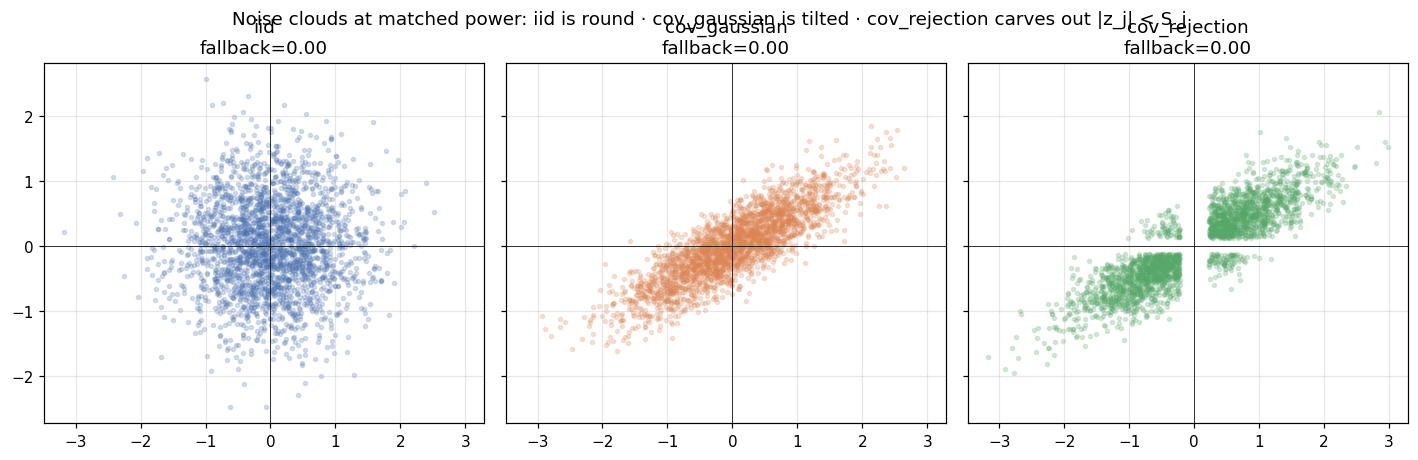

In [8]:
# The noise each mechanism actually produces (2500 draws) — shape is the whole point
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, name in zip(axes, ["iid", "cov_gaussian", "cov_rejection"]):
    m = builders[name]()
    Z = np.array([m.sample(rng) for _ in range(2500)])
    ax.scatter(Z[:, 0], Z[:, 1], s=7, alpha=.22, color=PAL[name])
    ax.axhline(0, color="k", lw=.5); ax.axvline(0, color="k", lw=.5); ax.set_aspect("equal")
    ax.set_title(f"{name}\nfallback={m.fallback_rate:.2f}")
plt.suptitle("Noise clouds at matched power: iid is round · cov_gaussian is tilted · "
             "cov_rejection carves out |z_j| < S_j"); plt.tight_layout(); plt.show()

**`noise_power` matching.** Passing a float rescales every mechanism's covariance to `trace == noise_power`,
so a comparison isolates *shape* from *amount*. Passing `None` uses each mechanism's own intrinsic scale.

In [9]:
for npow in [None, 1.0, 4.0]:
    m = ph.mech_cov_gaussian(y, D, S, noise_power=npow)
    print(f"noise_power={str(npow):5s} -> trace(cov) = {np.trace(m.cov):.4f}")

noise_power=None  -> trace(cov) = 0.0082
noise_power=1.0   -> trace(cov) = 1.0000
noise_power=4.0   -> trace(cov) = 4.0000


**The seam in action — a custom mechanism.** Anything that returns a `NoiseModel` works. Here is a Laplace
mechanism in five lines; it drops straight into `evaluate` and `sweep` alongside the built-ins (Part 8).

In [10]:
def mech_laplace(y, D, S, noise_power=None, **cfg):
    p = y.size
    scale = np.sqrt(noise_power / (2*p)) if noise_power is not None else float(np.abs(D).mean())
    return ph.NoiseModel(lambda rng: rng.laplace(0, scale, p),
                         cov=None, nominal_cov=2*scale**2*np.eye(p))

m = mech_laplace(y, D, S, noise_power=1.0)
print("custom Laplace NoiseModel — one draw:", np.round(m.sample(rng), 3))

custom Laplace NoiseModel — one draw: [-0.188 -0.471]


## Part 4 — Structural diagnostics (`cov_diagnostics`)

Before drawing a single noise sample, inspect the covariance **object** itself. `covariance_report` (and the
convenience `compare_pipelines`) surface things the outcome metrics structurally cannot see:

- the **mean-identity oracle** `Cov(LOO) == Cov(data)/(N−1)²` — a correctness check that must hold for the mean;
- **degeneracy** — zero / rank-deficient covariance or zero sensitivity (a mechanism that would add *no* noise);
- **data-vs-LOO** correlation divergence and **sign flips**;
- the **eigenvalue spectrum / condition number** (how anisotropic the noise is — the low-rank motivation).

`jitter_probe` then tells you whether a zero is genuine or just a discreteness artifact.

In [11]:
data = s_tab.sample(60, rng)
pipes = {"mean": ph.pipeline_mean, "median": ph.pipeline_median, "variance": ph.pipeline_variance}
reports = cd.compare_pipelines(data, pipes)   # prints a structural report per statistic


MEAN  (output=[70.166  1.708])
  sensitivity      : [0.3723 0.0059]
  eigenvalues      : [0.     0.0315]   rank 2/2   cond 12910.7
  corr  data=+0.401   LOO=0.401
  mean-identity err: 8.94e-19

MEDIAN  (output=[70.919  1.715])
  sensitivity      : [0.0103 0.    ]
  eigenvalues      : [0.     0.0001]   rank 2/2   cond 1140122.0
  corr  data=+0.401   LOO=0.2
  mean-identity err: 3.14e-02

VARIANCE  (output=[1.07839e+02 1.00000e-02])
  sensitivity      : [6.4871e+00 1.9000e-03]
  eigenvalues      : [0.     4.3249]   rank 2/2   cond 33324582.6
  corr  data=+0.401   LOO=-0.025   <-- SIGN FLIP
  mean-identity err: 4.29e+00


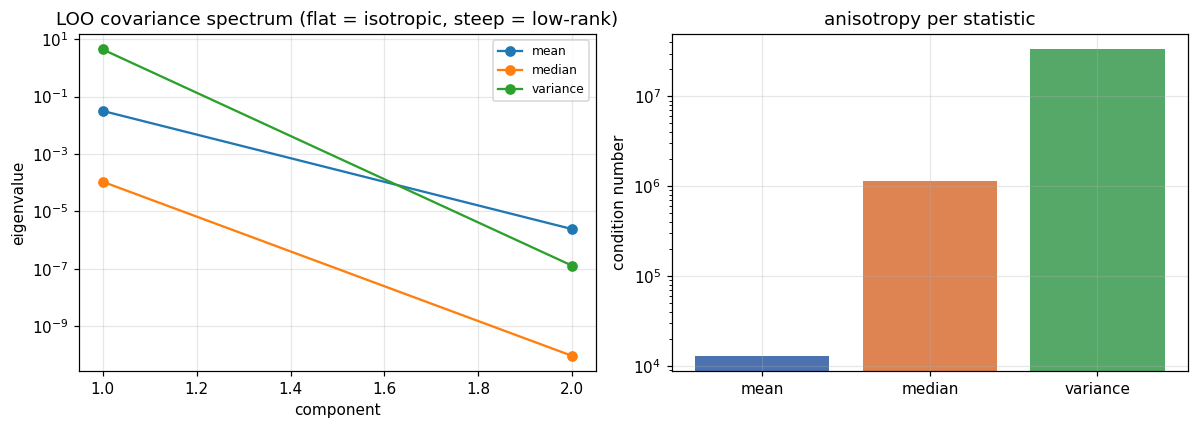

In [12]:
# The eigen-spectrum / anisotropy of each statistic's LOO covariance
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nm, rep in reports.items():
    ev = np.sort(rep["eigenvalues"])[::-1]
    ax[0].plot(range(1, len(ev)+1), np.clip(ev, 1e-12, None), "o-", label=nm)
ax[0].set_yscale("log"); ax[0].set_xlabel("component"); ax[0].set_ylabel("eigenvalue")
ax[0].set_title("LOO covariance spectrum (flat = isotropic, steep = low-rank)"); ax[0].legend(fontsize=8)
conds = [reports[n]["condition_number"] for n in reports]
ax[1].bar(range(len(reports)), conds, color=[PAL["iid"], PAL["cov_gaussian"], PAL["cov_rejection"]])
ax[1].set_yscale("log"); ax[1].set_xticks(range(len(reports))); ax[1].set_xticklabels(list(reports))
ax[1].set_ylabel("condition number"); ax[1].set_title("anisotropy per statistic")
plt.tight_layout(); plt.show()

## Part 5 — The membership game, attackers, and the analytic oracle

The privacy test is a **remove-one membership game** with a conservative, well-informed attacker:

1. Fix a known background of **N−1** subjects.
2. A coin adds the **target** (world **IN**, N subjects) or not (world **OUT**, N−1).
3. The mechanism releases the noised statistic; the attacker guesses IN vs OUT from that release alone.

`evaluate` runs this once and returns a rich dict. Two attackers score it:

- **Empirical** — a held-out linear (LDA) attacker; `advantage = TPR − FPR` with a bootstrap CI.
- **Analytic oracle** — the exact Mahalanobis advantage, valid **only** when the noise is Gaussian *and the
  covariance is identical in both worlds*. It returns a number for `mech_iid` (fixed covariance) and `None`
  for data-dependent covariance mechanisms — an honesty guardrail, and a way to *validate* the empirical
  attacker where the closed form applies.

In [13]:
r = ph.evaluate(s_syn, ph.pipeline_mean, ph.mech_iid, N=50, noise_power=8.0,
                n_trials=4000, n_rel=40, seed=1)
print("keys:", sorted(r)[:12], "...\n")
print(f"empirical advantage : {r['empirical_adv']:.3f}  95% CI [{r['adv_ci_lo']:.3f}, {r['adv_ci_hi']:.3f}]")
print(f"analytic  advantage : {r['analytic_adv']:.3f}   <- oracle validates the attacker")
print(f"utility (rel_mse)   : {r['rel_mse']:.3f}   spearman {r['spearman']:.3f}   bias {r['bias_norm']:.3f}")
print(f"fallback rate       : {r['fallback_rate']:.3f}")

keys: ['N', 'adv_ci_hi', 'adv_ci_lo', 'analytic_adv', 'bias_norm', 'empirical_adv', 'fallback_rate', 'k', 'neighbour_corr_gap', 'neighbour_corr_released', 'neighbour_corr_true', 'noise_power'] ...

empirical advantage : 0.320  95% CI [0.285, 0.366]
analytic  advantage : 0.363   <- oracle validates the attacker
utility (rel_mse)   : 13.504   spearman 0.262   bias 0.528
fallback rate       : 0.000


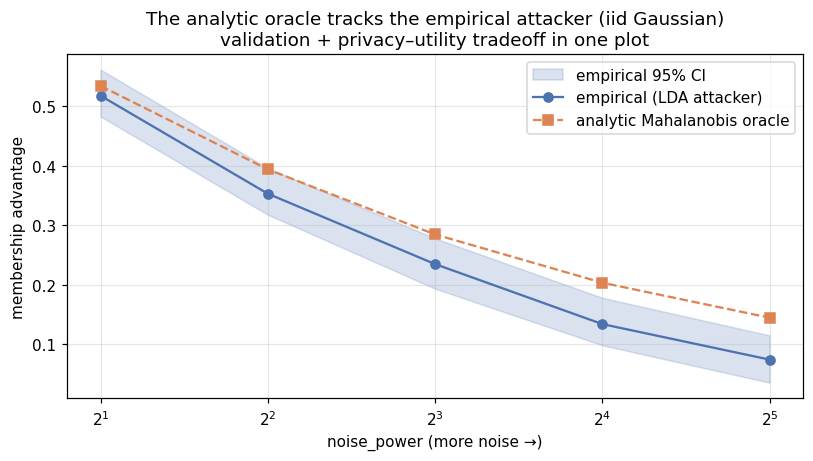

In [14]:
# Oracle vs empirical across the privacy-utility curve (iid, where the oracle is exact)
powers = [2, 4, 8, 16, 32]
emp, lo, hi, ana = [], [], [], []
for npow in powers:
    r = ph.evaluate(s_syn, ph.pipeline_mean, ph.mech_iid, N=50, noise_power=npow,
                    n_trials=4000, n_rel=20, seed=2)
    emp.append(r["empirical_adv"]); lo.append(r["adv_ci_lo"]); hi.append(r["adv_ci_hi"]); ana.append(r["analytic_adv"])
plt.figure(figsize=(7.5, 4.3))
plt.fill_between(powers, lo, hi, alpha=.2, color=PAL["iid"], label="empirical 95% CI")
plt.plot(powers, emp, "o-", color=PAL["iid"], label="empirical (LDA attacker)")
plt.plot(powers, ana, "s--", color=PAL["cov_gaussian"], label="analytic Mahalanobis oracle")
plt.xscale("log", base=2); plt.xlabel("noise_power (more noise →)"); plt.ylabel("membership advantage")
plt.title("The analytic oracle tracks the empirical attacker (iid Gaussian)\nvalidation + privacy–utility tradeoff in one plot")
plt.legend(); plt.tight_layout(); plt.show()

**Target modes.** `target_mode='k_sigma'` (default) uses a synthetic `mean + k·SD` target — an explicit,
elevated stress test. `target_mode='actual'` uses a real held-out subject, guaranteed not to be duplicated in
its known background — a more realistic attacker. The mode is recorded in the output.

In [15]:
for mode in ["k_sigma", "actual"]:
    r = ph.evaluate(s_tab, ph.pipeline_mean, ph.mech_cov_gaussian, N=40, noise_power=0.3,
                    n_trials=3000, n_rel=30, seed=3, target_mode=mode)
    print(f"target_mode={mode:8s} -> advantage {r['empirical_adv']:.3f}  (mode recorded: {r['target_mode']})")

target_mode=k_sigma  -> advantage 0.368  (mode recorded: k_sigma)
target_mode=actual   -> advantage 0.231  (mode recorded: actual)


## Part 6 — The utility panel: why spatial structure is the headline

`utility_panel` reports four complementary numbers, not one:

- `rel_mse` — pixelwise magnitude of distortion;
- `neighbour_corr_gap` — |neighbour-correlation(true) − neighbour-correlation(released)|, **the spatial axis MSE
  is blind to**; iid noise inflates it while structure-aware noise preserves it;
- `spearman` — rank/ordering preservation;
- `bias_norm` — systematic bias (rejection can bias the mean).

The demonstration: on a spatially-correlated patch, **iid and covariance-aware noise can have the same MSE yet
wildly different spatial fidelity.** This is the whole motivation for shaping the noise.

mechanism        rel_mse  nbr_corr_gap  spearman
iid               10.130         0.321     0.298
cov_gaussian      10.903         0.107     0.401


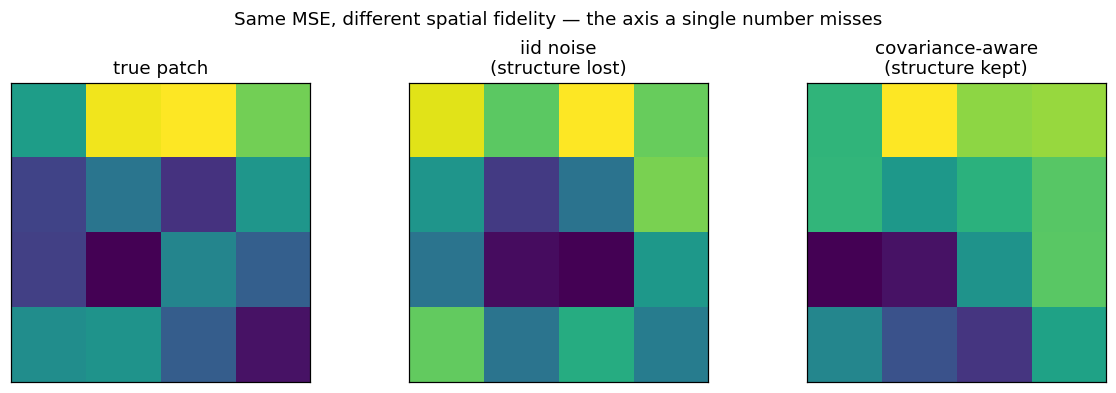

In [16]:
# same noise_power for both -> the ONLY difference is noise shape
res = {}
for name, mech in [("iid", ph.mech_iid), ("cov_gaussian", ph.mech_cov_gaussian)]:
    res[name] = ph.evaluate(s_syn, ph.pipeline_mean, mech, N=50, noise_power=6.0,
                            n_trials=500, n_rel=120, seed=1)
print(f"{'mechanism':14s} {'rel_mse':>9s} {'nbr_corr_gap':>13s} {'spearman':>9s}")
for name, r in res.items():
    print(f"{name:14s} {r['rel_mse']:9.3f} {r['neighbour_corr_gap']:13.3f} {r['spearman']:9.3f}")

# a picture: the true patch vs one iid- and one cov-noised release (middle slice)
rng2 = np.random.default_rng(7); pool = s_syn.sample(50, rng2); g_true = pool.mean(0).reshape(4,4,4)
yv, Dv, Sv = ph.loo_artifacts(pool, ph.pipeline_mean)
rel_iid = (g_true.ravel() + ph.mech_iid(yv,Dv,Sv,noise_power=6.0).sample(rng2)).reshape(4,4,4)
rel_cov = (g_true.ravel() + ph.mech_cov_gaussian(yv,Dv,Sv,noise_power=6.0).sample(rng2)).reshape(4,4,4)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (t, m) in zip(ax, [("true patch", g_true), ("iid noise\n(structure lost)", rel_iid),
                          ("covariance-aware\n(structure kept)", rel_cov)]):
    im = a.imshow(m[:, :, 2], cmap="viridis"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
plt.suptitle("Same MSE, different spatial fidelity — the axis a single number misses"); plt.tight_layout(); plt.show()

## Part 7 — The reconstruction attack (stronger than membership)

Reconstruction tries to recover the target's *values* from the release, given the known background. It is
honest only for **identifiable** statistics — essentially linear ones (the mean), where the target is a linear
function of the release. For non-identifiable statistics (variance, median: many inputs map to one output) it
reports `identifiable=False` and returns a best-effort number that must not be read as precise. Advantage is
measured against a naive population-mean baseline (a lower bound, one attacker).

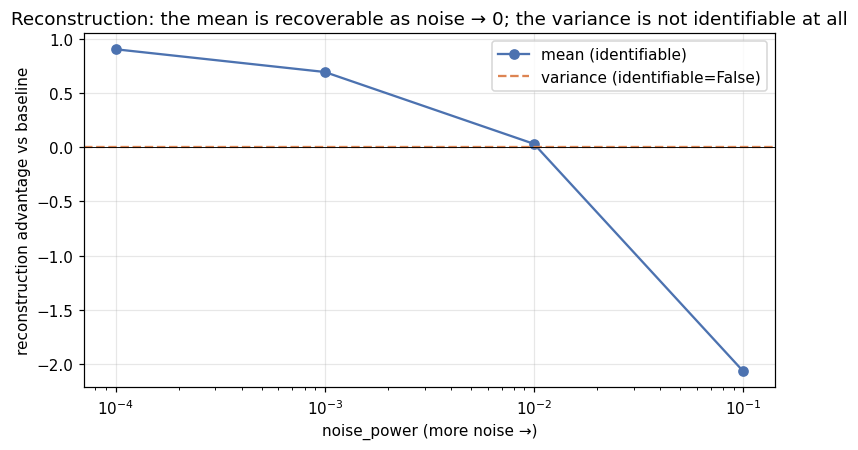

mean identifiable: True | variance identifiable: False


In [17]:
s_r = ph.TabularSource(rng.multivariate_normal([10, 5], [[1, .6], [.6, 1]], 200), N=30)
powers = [1e-4, 1e-3, 1e-2, 1e-1]
adv_mean = []
for npow in powers:
    r = ph.evaluate(s_r, ph.pipeline_mean, ph.mech_cov_gaussian, N=30, k=3.0, noise_power=npow,
                    n_trials=200, n_rel=200, seed=1, reconstruction=True, target_mode="k_sigma")
    adv_mean.append(r["recon_advantage"])
r_var = ph.evaluate(s_r, ph.pipeline_variance, ph.mech_cov_gaussian, N=30, noise_power=1e-3,
                    n_trials=200, n_rel=200, seed=1, reconstruction=True, target_mode="k_sigma")

plt.figure(figsize=(7.2, 4.2))
plt.plot(powers, adv_mean, "o-", color=PAL["iid"], label="mean (identifiable)")
plt.axhline(r_var["recon_advantage"], color=PAL["cov_gaussian"], ls="--",
            label=f"variance (identifiable={r_var['recon_identifiable']})")
plt.xscale("log"); plt.axhline(0, color="k", lw=.6)
plt.xlabel("noise_power (more noise →)"); plt.ylabel("reconstruction advantage vs baseline")
plt.title("Reconstruction: the mean is recoverable as noise → 0; the variance is not identifiable at all")
plt.legend(); plt.tight_layout(); plt.show()
print("mean identifiable:", True, "| variance identifiable:", r_var["recon_identifiable"])

## Part 8 — Sweeps and aggregation: the full experimental workflow

`sweep` runs a grid over **mechanism × N × noise_power × seed** on one source and returns a tidy per-seed
DataFrame; `aggregate_sweep` collapses the seeds into **mean ± 95% CI** (capturing data-draw and attacker
variability, not just the within-run bootstrap). This is how you turn the harness into an experiment. Our
custom `mech_laplace` rides along to prove the seam holds end-to-end.

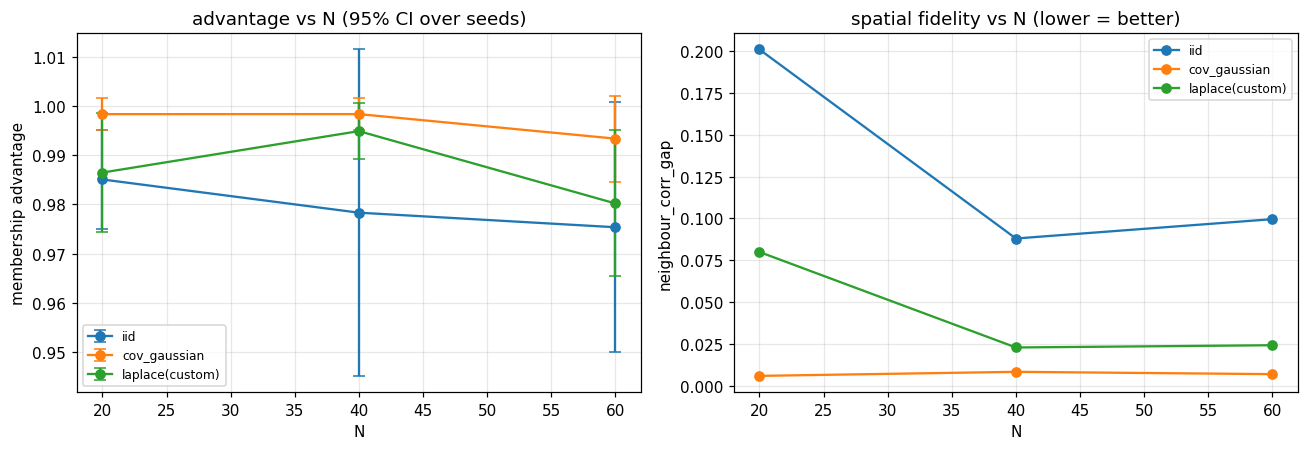

In [18]:
mechs = {"iid": ph.mech_iid, "cov_gaussian": ph.mech_cov_gaussian, "laplace(custom)": mech_laplace}

# advantage vs N, each mechanism at its own intrinsic scale (power_scales=None)
dfN = ph.sweep(s_syn, ph.pipeline_mean, mechs, N_list=[20, 40, 60], power_scales=None,
               seeds=(1, 2, 3), n_trials=800, n_rel=40)
aggN = ph.aggregate_sweep(dfN, group_cols=("mechanism", "N"),
                          metrics=("empirical_adv", "neighbour_corr_gap"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for name in mechs:
    g = aggN[aggN.mechanism == name].sort_values("N")
    yerr = [g.empirical_adv_mean - g.empirical_adv_lo, g.empirical_adv_hi - g.empirical_adv_mean]
    ax[0].errorbar(g.N, g.empirical_adv_mean, yerr=yerr, fmt="o-", capsize=4, label=name)
    ax[1].plot(g.N, g.neighbour_corr_gap_mean, "o-", label=name)
ax[0].set_xlabel("N"); ax[0].set_ylabel("membership advantage"); ax[0].set_title("advantage vs N (95% CI over seeds)"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("N"); ax[1].set_ylabel("neighbour_corr_gap"); ax[1].set_title("spatial fidelity vs N (lower = better)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [19]:
# power_scales: sweep noise power RELATIVE to the iid budget (for iid-vs-Gaussian comparisons)
dfP = ph.sweep(s_syn, ph.pipeline_mean, {"iid": ph.mech_iid, "cov_gaussian": ph.mech_cov_gaussian},
               N_list=[50], power_scales=(1, 3, 10), seeds=(1, 2, 3), n_trials=800, n_rel=40)
aggP = ph.aggregate_sweep(dfP, group_cols=("mechanism", "power_x"), metrics=("empirical_adv", "neighbour_corr_gap"))
print(aggP[["mechanism", "power_x", "empirical_adv_mean", "neighbour_corr_gap_mean"]].round(3).to_string(index=False))

   mechanism  power_x  empirical_adv_mean  neighbour_corr_gap_mean
cov_gaussian        1               0.962                    0.032
cov_gaussian        3               0.765                    0.067
cov_gaussian       10               0.445                    0.114
         iid        1               0.970                    0.066
         iid        3               0.852                    0.139
         iid       10               0.570                    0.228


## Part 9 — Inferential utility (`inference_eval`): does privatization preserve valid inference?

The utility panel asks "how close is the release to the clean output?". `inference_eval` asks a different
question: **does privatization change the scientific decision?** You supply a data generator, a statistic, and
a decide rule; it compares the clean and privatized *decisions* on the same simulated datasets and reports
**Type-I error** (under a null generator) and **power** (under an alternative), with a **paired bootstrap CI**
on the private−clean difference. `make_onesample_ttest` and `gaussian_generator` are ready-made callbacks.

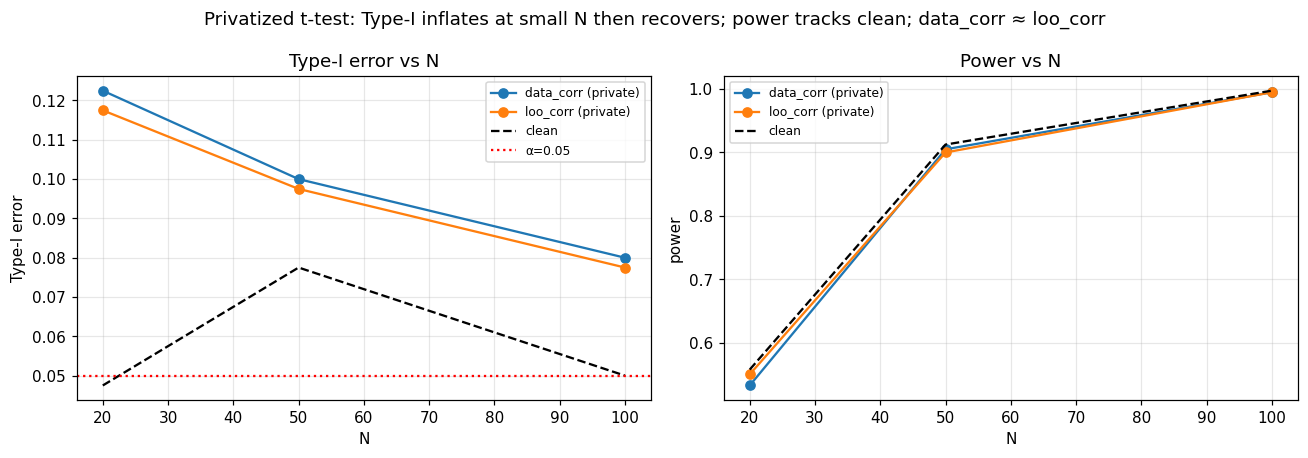

In [20]:
stat, decide = ie.make_onesample_ttest(alpha=0.05)
mechs_inf = {"data_corr": ph.mech_supervisor_data_corr(), "loo_corr": ph.mech_supervisor_loo_corr()}
dfI = ie.type1_power_sweep(ie.gaussian_generator(effect=0.0, corr=0.5, p=2),   # null  -> Type-I
                           ie.gaussian_generator(effect=0.5, corr=0.5, p=2),   # alt   -> power
                           stat, decide, mechs_inf, n_list=[20, 50, 100],
                           mc=400, seed=0, n_boot=500)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for scen, a, ttl, ref in [("type1", ax[0], "Type-I error vs N", 0.05), ("power", ax[1], "Power vs N", None)]:
    sub = dfI[(dfI.scenario == scen) & (dfI.variable == 0)]
    for m in mechs_inf:
        g = sub[sub.mechanism == m].sort_values("n")
        a.plot(g.n, g.reject_private, "o-", label=f"{m} (private)")
    g0 = sub.groupby("n").reject_clean.mean()
    a.plot(g0.index, g0.values, "k--", label="clean")
    if ref is not None: a.axhline(ref, color="r", ls=":", label="α=0.05")
    a.set_xlabel("N"); a.set_title(ttl); a.legend(fontsize=8)
ax[0].set_ylabel("Type-I error"); ax[1].set_ylabel("power")
plt.suptitle("Privatized t-test: Type-I inflates at small N then recovers; power tracks clean; data_corr ≈ loo_corr")
plt.tight_layout(); plt.show()

## Part 10 — A copy-paste end-to-end recipe

The whole workflow in one block: pick a source, a pipeline, a set of mechanisms, sweep, aggregate, read the
result. Change any one line to run a completely different study.

In [21]:
# 1) data              2) release pipeline        3) mechanisms to compare
source   = ph.SyntheticBlockSource(N=50, block_shape=(4,4,4), spatial_corr=0.7)
pipeline = ph.pipeline_mean
mechs    = {"iid": ph.mech_iid, "cov_gaussian": ph.mech_cov_gaussian}

# 4) sweep + aggregate                              5) read privacy & utility with CIs
df  = ph.sweep(source, pipeline, mechs, N_list=[50], power_scales=(1, 5), seeds=(1, 2, 3), n_trials=800, n_rel=40)
out = ph.aggregate_sweep(df, group_cols=("mechanism", "power_x"),
                         metrics=("empirical_adv", "rel_mse", "neighbour_corr_gap"))
print(out[["mechanism", "power_x", "empirical_adv_mean", "rel_mse_mean", "neighbour_corr_gap_mean"]]
      .round(3).to_string(index=False))
print("\nRead-off: at matched power, both leak similarly (advantage), but cov_gaussian keeps far more spatial"
      "\nstructure (smaller neighbour_corr_gap) — the reason to shape the noise.")

   mechanism  power_x  empirical_adv_mean  rel_mse_mean  neighbour_corr_gap_mean
cov_gaussian        1               0.962         0.239                    0.032
cov_gaussian        5               0.665         1.194                    0.087
         iid        1               0.970         0.264                    0.066
         iid        5               0.759         1.318                    0.179

Read-off: at matched power, both leak similarly (advantage), but cov_gaussian keeps far more spatial
structure (smaller neighbour_corr_gap) — the reason to shape the noise.


## API cheat-sheet

**Sources** (`privacy_harness`) — `TabularSource(table, N)` · `GeneratedPopulationSource(N,p,correlation,base_std)` ·
`SyntheticBlockSource(N,block_shape,spatial_corr,base_std)` · `ArrayBlockSource(volumes,mask,block_shape,N,seed)` ·
loaders `load_oasis`, `load_nifti_dir`, `oasis_source`. Contract: `.block_shape,.p,.N,.sample(n,rng)->(n,p)`.

**Pipelines / LOO** — `pipeline_mean` · `pipeline_median` · `pipeline_variance` · `target_ksigma(subjects,k)` ·
`loo_artifacts(stack,pipeline) -> (y, D, S)`.

**Mechanisms** — `mech_iid` · `mech_cov_gaussian` · `mech_cov_rejection` ·
`make_covsource_mechanism(cov_source={'data','loo'}, scale_rule={'supervisor','raw'}, epsilon, ddof, max_draws)` ·
named: `mech_supervisor_data_corr`, `mech_supervisor_loo_corr`, `mech_direct_loo_cov`. Signature
`mechanism(y,D,S,noise_power=None,subjects=None,**cfg) -> NoiseModel`; `NoiseModel.sample/.cov/.nominal_cov/.fallback_rate`.

**Evaluate / sweep** — `evaluate(source,pipeline,mechanism,mech_cfg,N,k,noise_power,n_trials,n_rel,seed,reconstruction,target_mode)` ·
`sweep(source,pipeline,mechanisms,N_list,power_scales,k,n_trials,n_rel,seeds,mech_cfgs)` ·
`aggregate_sweep(df,group_cols,metrics)`. Attackers/oracle: `empirical_advantage`, `analytic_advantage`,
`reconstruction_attack`. Utility: `utility_panel`.

**Structural** (`cov_diagnostics`) — `covariance_report(data,pipeline,...)` · `print_report` ·
`compare_pipelines(data,pipelines)` · `jitter_probe(data,pipeline,scales,reps)`. Keys include `mean_identity_err`,
`degenerate`, `data_corr/loo_corr`, `sign_flip`, `eigenvalues`, `condition_number`.

**Inferential** (`inference_eval`) — `make_onesample_ttest(alpha)` · `gaussian_generator(effect,corr,p)` ·
`inference_experiment(...)` · `inference_sweep(...)` · `type1_power_sweep(null_gen,alt_gen,...)`.

### Remember
`noise_power` is a fair-comparison knob, **not** ε. Advantage is a **lower bound** on leakage, compared
between mechanisms — never a DP guarantee. Structural characterization (Part 4) and inference (Part 9) answer
questions the outcome metrics cannot.